# Foodster: где теряются пользователи приложения доставки и какие каналы привлечения окупаются

**Роль:** продуктовый аналитик (внешний, полный цикл) · **Период:** апрель 2025 – н.в. · **Клиент:** Foodster — доставка еды (мобильное приложение, запуск франшизы в новом регионе)

## Бизнес-контекст

Foodster запускал франшизу сервиса доставки еды в новом городе. Продукт — мобильное
приложение; привлечение шло через несколько каналов одновременно (Telegram-сообщества,
органика, таргет, контекст, реферальная программа). Я был единственным аналитиком
на проекте и отвечал за полный цикл: от сбора событий до рекомендаций бизнесу.

**Две задачи от клиента:**
1. Пользователи устанавливают приложение, но многие не доходят до первого заказа — где теряются?
2. Маркетинговый бюджет размазан по каналам — какие каналы реально окупаются?

> ⚠️ **Дисклеймер о данных.** Реальные данные клиента под NDA. Для публичной демонстрации
> методологии структура воссоздана синтетически (`generate_data.py`) с сохранением характера
> реальных закономерностей. Цифры иллюстративные; выводы и порядок величин соответствуют
> реальному кейсу.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})

users = pd.read_csv("users.csv", parse_dates=["installed_at"])
ret = pd.read_csv("retention.csv")
unit = pd.read_csv("unit_economics.csv")

print(f"Пользователей: {len(users):,}")
users[["user_id", "installed_at", "channel", "ab_group", "first_order"]].head()

Пользователей: 14,000


,user_id,installed_at,channel,ab_group,first_order
0,1,2025-04-15 15:00:00,Реферальная программа,control,False
1,2,2025-04-18 15:00:00,Таргетированная реклама,control,False
2,3,2025-04-16 22:00:00,Органический поиск,control,False
3,4,2025-04-25 19:00:00,Таргетированная реклама,control,False
4,5,2025-04-22 16:00:00,Таргетированная реклама,control,False


## Задача 1. Воронка приложения: где теряются пользователи

Этапы: установка → регистрация → открыл меню → собрал корзину → ввёл адрес доставки →
первый заказ. Смотрим по «чистой» группе (без изменений интерфейса).

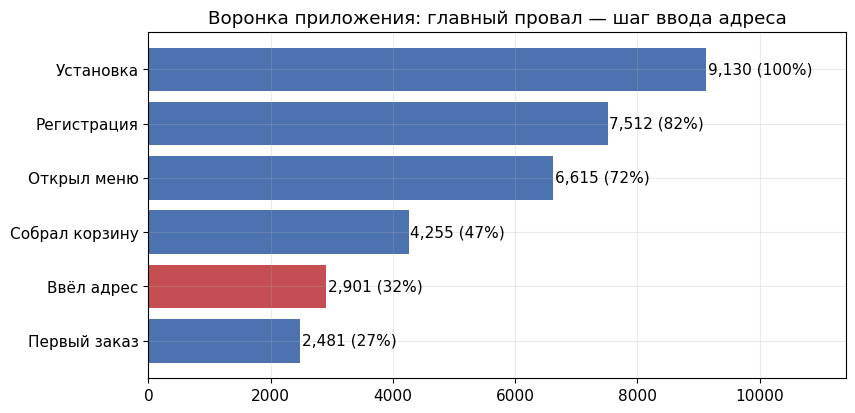

Конверсия по шагам: {'Установка': 100, 'Регистрация': 82, 'Открыл меню': 88, 'Собрал корзину': 64, 'Ввёл адрес': 68, 'Первый заказ': 86}
Отток на шаге ввода адреса: 32% — крупнейшая потеря в воронке


In [2]:
ctrl = users[users["ab_group"] == "control"]
stages = {
    "Установка": ctrl["user_id"].notna(),
    "Регистрация": ctrl["registered"],
    "Открыл меню": ctrl["opened_menu"],
    "Собрал корзину": ctrl["built_cart"],
    "Ввёл адрес": ctrl["entered_address"],
    "Первый заказ": ctrl["first_order"],
}
funnel = pd.Series({k: v.sum() for k, v in stages.items()})
conv_step = (funnel / funnel.shift(1)).fillna(1)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#4C72B0"] * 6
colors[4] = "#C44E52"  # шаг адреса — красным
ax.barh(list(funnel.index)[::-1], funnel.values[::-1], color=colors[::-1])
for i, name in enumerate(funnel.index[::-1]):
    ax.text(funnel[name] + 30, i, f"{funnel[name]:,} ({funnel[name]/funnel.iloc[0]:.0%})", va="center")
ax.set_xlim(0, funnel.max() * 1.25)
ax.set_title("Воронка приложения: главный провал — шаг ввода адреса")
plt.show()

drop_addr = 1 - funnel["Ввёл адрес"] / funnel["Собрал корзину"]
print(f"Конверсия по шагам: {(conv_step*100).round(0).astype(int).to_dict()}")
print(f"Отток на шаге ввода адреса: {drop_addr:.0%} — крупнейшая потеря в воронке")

**Главная точка потерь — шаг ввода адреса доставки: ~32% пользователей, собравших корзину,
не доходят до заказа именно здесь.** Остальные шаги конвертируют ожидаемо.

Разбор шага показал типовые проблемы UX ручного ввода адреса: пользователь на телефоне
вынужден вручную набирать улицу и дом, ошибается, не находит свой адрес, бросает корзину.
Гипотеза: упростить ввод адреса → вернуть часть потерянной конверсии.

## Задача 1 (решение). A/B-тест упрощённого шага адреса

**Гипотеза:** автоопределение геолокации + подсказки при вводе + сохранение истории адресов
снизят отток на шаге адреса и поднимут конверсию в первый заказ.

**Дизайн:** новые пользователи случайно делятся 50/50. Control — старый ручной ввод;
Test — новый шаг с геолокацией и подсказками. Метрика — сквозная конверсия
установка → первый заказ.

In [3]:
def two_prop_ztest(x1, n1, x2, n2):
    """z-тест равенства двух долей."""
    p = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    z = (x1 / n1 - x2 / n2) / se
    return z, 2 * (1 - stats.norm.cdf(abs(z)))

ab = users[users["ab_eligible"]].copy()
g = ab.groupby("ab_group").agg(users=("user_id", "count"), orders=("first_order", "sum"))
g["cr"] = g["orders"] / g["users"]

c, t = g.loc["control"], g.loc["test"]
uplift = t["cr"] / c["cr"] - 1
z, p = two_prop_ztest(int(t["orders"]), int(t["users"]), int(c["orders"]), int(c["users"]))
diff = t["cr"] - c["cr"]
se = np.sqrt(t["cr"]*(1-t["cr"])/t["users"] + c["cr"]*(1-c["cr"])/c["users"])

print(g.assign(cr=lambda d: (d["cr"]*100).round(1)))
print(f"\nОтносительный uplift: {uplift:+.0%}")
print(f"Разница долей: {diff:+.1%} п.п., 95% CI [{diff-1.96*se:+.1%}; {diff+1.96*se:+.1%}]")
print(f"z = {z:.2f}, p-value = {p:.1e} — эффект статистически значим")

          users  orders    cr
ab_group                     
control    4823    1352  28.0
test       4870    1554  31.9

Относительный uplift: +14%
Разница долей: +3.9% п.п., 95% CI [+2.1%; +5.7%]
z = 4.17, p-value = 3.1e-05 — эффект статистически значим


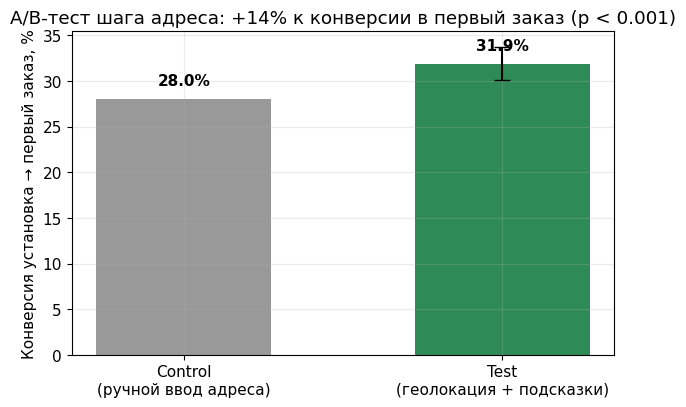

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(["Control\n(ручной ввод адреса)", "Test\n(геолокация + подсказки)"],
       [c["cr"]*100, t["cr"]*100], color=["#999999", "#2E8B57"], width=0.55)
ax.errorbar(1, t["cr"]*100, yerr=1.96*se*100, color="black", capsize=6, fmt="none")
for i, v in enumerate([c["cr"], t["cr"]]):
    ax.text(i, v*100 + 1.5, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Конверсия установка → первый заказ, %")
ax.set_title(f"A/B-тест шага адреса: {uplift:+.0%} к конверсии в первый заказ (p < 0.001)")
plt.show()

**Результат: конверсия в первый заказ выросла на ~14% (относительных), эффект статистически
значим.** Доверительный интервал не пересекает ноль. Решение раскатано на всех пользователей.

Это прямой ответ на задачу 1: нашли провал в воронке → сформулировали гипотезу →
проверили экспериментом → получили измеримый рост.

## Задача 2. Какие каналы привлечения окупаются

Бюджет был размазан по каналам примерно поровну. Чтобы понять, куда его двигать,
нужно сравнить каналы не по стоимости клика, а по **качеству приводимых пользователей** —
то есть по удержанию (Retention) и окупаемости (LTV против CAC).

### Retention по каналам

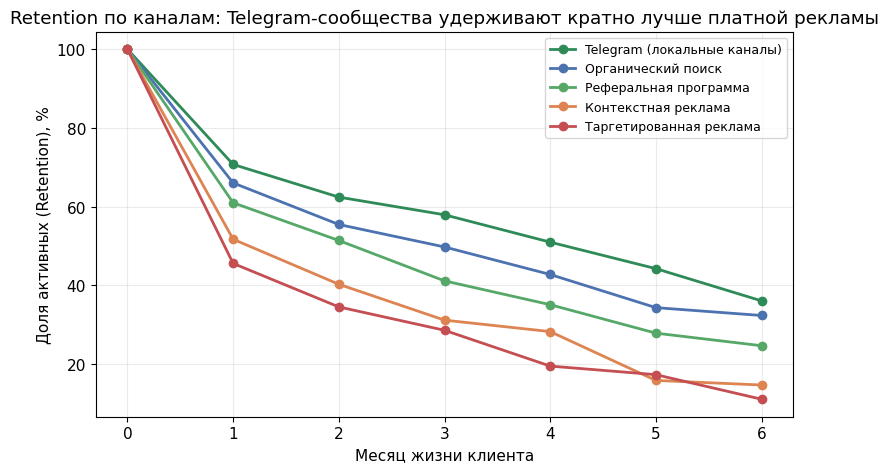

Retention на 3-й месяц: Telegram=58%, таргет=29%
Пользователи из Telegram-сообществ удерживаются в ~2.0 раза лучше, чем из таргетированной рекламы


In [5]:
ret_m = ret.groupby(["channel", "month_k"])["active"].mean().unstack(0)

order = ret_m.iloc[3].sort_values(ascending=False).index
palette = {"Telegram (локальные каналы)": "#2E8B57", "Органический поиск": "#4C72B0",
           "Реферальная программа": "#55A868", "Контекстная реклама": "#DD8452",
           "Таргетированная реклама": "#C44E52"}
fig, ax = plt.subplots(figsize=(9, 5))
for ch in order:
    ax.plot(ret_m.index, ret_m[ch]*100, marker="o", lw=2, label=ch, color=palette.get(ch))
ax.set_xlabel("Месяц жизни клиента")
ax.set_ylabel("Доля активных (Retention), %")
ax.set_title("Retention по каналам: Telegram-сообщества удерживают кратно лучше платной рекламы")
ax.legend(fontsize=9)
plt.show()

m3 = ret[ret["month_k"] == 3].groupby("channel")["active"].mean()
ratio = m3["Telegram (локальные каналы)"] / m3["Таргетированная реклама"]
print(f"Retention на 3-й месяц: Telegram={m3['Telegram (локальные каналы)']:.0%}, "
      f"таргет={m3['Таргетированная реклама']:.0%}")
print(f"Пользователи из Telegram-сообществ удерживаются в ~{ratio:.1f} раза лучше, "
      f"чем из таргетированной рекламы")

**Пользователи из локальных Telegram-сообществ удерживаются примерно в 2 раза лучше,
чем из таргетированной рекламы.** Логика понятна: в локальном сообществе аудитория
тёплая и лояльная к местному бренду, а таргет приводит «холодных» пользователей,
которые часто делают один заказ и уходят.

### Юнит-экономика: LTV против CAC

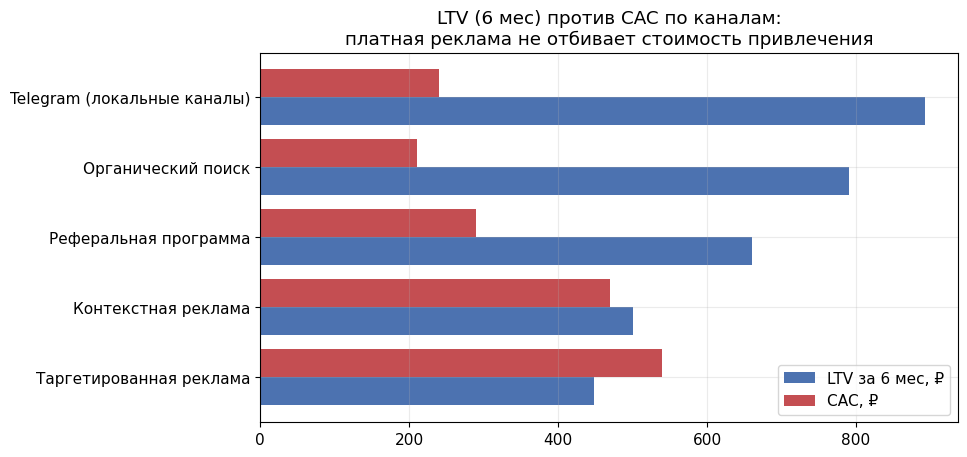

                    channel  CAC  LTV_6m           окупаемость
Telegram (локальные каналы)  240     892                 1 мес
         Органический поиск  210     791                 1 мес
    Таргетированная реклама  540     448 не окупается за 6 мес
      Реферальная программа  290     661                 2 мес
        Контекстная реклама  470     500                 6 мес


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8))
u = unit.sort_values("LTV_6m", ascending=True)
x = np.arange(len(u))
ax.barh(x - 0.2, u["LTV_6m"], height=0.4, label="LTV за 6 мес, ₽", color="#4C72B0")
ax.barh(x + 0.2, u["CAC"], height=0.4, label="CAC, ₽", color="#C44E52")
ax.set_yticks(x); ax.set_yticklabels(u["channel"])
ax.legend()
ax.set_title("LTV (6 мес) против CAC по каналам:\nплатная реклама не отбивает стоимость привлечения")
plt.show()

disp = unit.copy()
disp["окупаемость"] = disp["payback_month"].apply(
    lambda m: f"{int(m)} мес" if pd.notna(m) else "не окупается за 6 мес")
print(disp[["channel", "CAC", "LTV_6m", "окупаемость"]].to_string(index=False))

**Ключевой вывод по экономике каналов:**

- **Telegram-сообщества и органика** — дешёвые в привлечении и хорошо удерживают,
  поэтому окупаются за 1–2 месяца.
- **Таргетированная реклама** — самый дорогой канал с худшим удержанием: за 6 месяцев
  она **не отбивает** стоимость привлечения (LTV < CAC).
- Контекст и реферальная программа — посередине.

То есть бюджет работал неэффективно: значительная его часть уходила в таргет,
который не окупается, а недофинансированы были каналы, которые приносят лояльных
пользователей дёшево.

### Рекомендация и эффект: перераспределение бюджета

На основе анализа я предложил сдвинуть бюджет от таргета и контекста в сторону
Telegram-сообществ, органики и реферальной программы. Смотрим, как это меняет
средневзвешенный CAC.

Средневзвешенный CAC до перераспределения:  371 ₽
Средневзвешенный CAC после перераспределения: 316 ₽
Снижение CAC: -15%


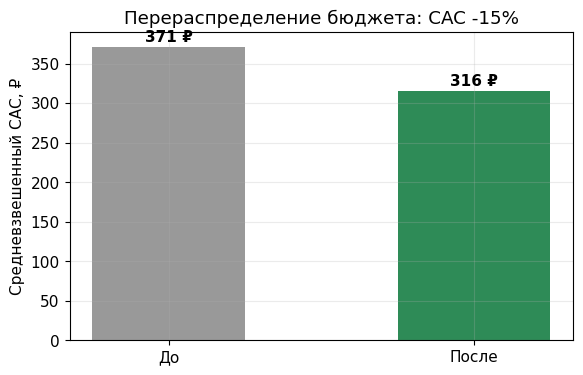

In [7]:
# доли бюджета: было (примерно поровну с перекосом в платку) -> стало (сдвиг в эффективные каналы)
share_before = {"Telegram (локальные каналы)": 0.22, "Органический поиск": 0.18,
                "Таргетированная реклама": 0.34, "Реферальная программа": 0.14,
                "Контекстная реклама": 0.12}
share_after = {"Telegram (локальные каналы)": 0.32, "Органический поиск": 0.24,
               "Таргетированная реклама": 0.20, "Реферальная программа": 0.18,
               "Контекстная реклама": 0.06}
cac = dict(zip(unit["channel"], unit["CAC"]))

cac_before = sum(share_before[c] * cac[c] for c in cac)
cac_after = sum(share_after[c] * cac[c] for c in cac)

print(f"Средневзвешенный CAC до перераспределения:  {cac_before:.0f} ₽")
print(f"Средневзвешенный CAC после перераспределения: {cac_after:.0f} ₽")
print(f"Снижение CAC: {cac_after/cac_before - 1:+.0%}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(["До", "После"], [cac_before, cac_after], color=["#999999", "#2E8B57"], width=0.5)
for i, v in enumerate([cac_before, cac_after]):
    ax.text(i, v + 6, f"{v:.0f} ₽", ha="center", fontweight="bold")
ax.set_ylabel("Средневзвешенный CAC, ₽")
ax.set_title(f"Перераспределение бюджета: CAC {cac_after/cac_before - 1:+.0%}")
plt.show()

**Перераспределение бюджета в пользу окупаемых каналов снижает средневзвешенный CAC
примерно на 15%** — при том же объёме привлечения компания платит за клиента меньше
и получает более лояльную базу.

## Итоги

| Задача | Что сделано | Результат |
|---|---|---|
| Где теряются пользователи | Анализ воронки приложения | Найден главный провал: ~32% оттока на шаге ввода адреса |
| Вернуть конверсию | A/B-тест упрощённого шага адреса (геолокация, подсказки) | **+14% к конверсии в первый заказ**, эффект значим, раскатано на всех |
| Качество каналов | Когортный Retention-анализ | Telegram-сообщества удерживают ~×2 к таргету |
| Куда двигать бюджет | Юнит-экономика (LTV vs CAC, окупаемость) | Таргет не окупается за 6 мес; перераспределение → **CAC −15%** |

**Стек оригинального проекта:** SQL (выгрузка событий и заказов, витрина данных),
Power BI (дашборд ключевых метрик), PowerPoint (презентация результатов клиенту).
**Стек демонстрации:** Python — pandas, numpy, matplotlib, scipy.